# Gate 3 · Transparent metrics and keyness

This executed notebook reads only generated Gate 3 artifacts: the canonical metrics output, the keyness manifest, and the two published unigram tables. It does not recompute metric or keyness formulas.

## Orientation and claim boundaries

The primary comparison uses **119,798 eligible title pairs**. The shared-stage sensitivity uses **115,134 pairs (96.1% overlap)**. Positive z-scores indicate relative association with short titles; negative z-scores indicate relative association with official titles. The sensitivity set is nested within the primary set, not independent.

Counts are **token frequency**, not document frequency. Normalized rates are relative frequencies, not posterior probabilities. The pooled-frequency minimum of 25 is a discovery filter, not a significance threshold. These outputs do not establish bias, intent, persuasion, accessibility improvement, comprehension, policy quality, significance, importance, meaningfulness, causation, or classifier performance.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def find_root():
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "data/processed/title_pairs_with_metrics.csv.gz").exists() and (p / "reports/tables/keyness_summary.json").exists(): return p
    raise FileNotFoundError("repository root not found")
ROOT = find_root(); FIGURES = ROOT / "reports/figures"; FIGURES.mkdir(exist_ok=True)
summary = json.loads((ROOT / "reports/tables/keyness_summary.json").read_text())
primary = pd.read_csv(ROOT / "reports/tables/weighted_log_odds_unigrams.csv")
shared = pd.read_csv(ROOT / "reports/tables/weighted_log_odds_unigrams_shared_stage.csv")
REQUIRED_KEYNESS_COLUMNS = {"token","official_count","short_count","pooled_count","z_score","short_rank","official_rank"}
assert set(primary.columns) >= REQUIRED_KEYNESS_COLUMNS
assert set(shared.columns) >= REQUIRED_KEYNESS_COLUMNS
metrics = pd.read_csv(ROOT / "data/processed/title_pairs_with_metrics.csv.gz", usecols=["surface_simplification_candidate","values_framing_candidate","threat_framing_candidate","mechanism_obscuring_candidate","readability_both_eligible_5","readability_both_eligible_10"])
assert summary["subsets"]["all"]["pair_count"] == 119798 and summary["subsets"]["shared_stage"]["pair_count"] == 115134
assert len(primary) == 5615 and len(shared) == 5525 and len(metrics) == 119798
print(f"Loaded {len(metrics):,} metric rows; {len(primary):,} primary terms; {len(shared):,} shared-stage terms.")


Loaded 119,798 metric rows; 5,615 primary terms; 5,525 shared-stage terms.


## Corpus and method summary

Generated from the published keyness manifest. Official titles contribute 1,884,783 analyzed tokens and short titles 569,795 (about 3.3 times as many). sklearn's base stopword set is 318 tokens and the effective set is 317: only `bill` is actually removed from the base set by the four retained exceptions; `act`, `law`, and `resolution` were not base stopwords.

In [2]:
a, s = summary["subsets"]["all"], summary["subsets"]["shared_stage"]
corpus = pd.DataFrame([("Primary / all eligible pairs",a["pair_count"],a["official_tokens"],a["short_tokens"],a["eligible_term_count"],"119,798-pair denominator"),("Shared-stage sensitivity",s["pair_count"],s["official_tokens"],s["short_tokens"],s["eligible_term_count"],"115,134 pairs; 96.1% of primary")], columns=["comparison","pairs","official tokens","short tokens","eligible unigrams","denominator note"])
display(corpus.style.format({"pairs":"{:,}","official tokens":"{:,}","short tokens":"{:,}","eligible unigrams":"{:,}"}).hide(axis="index"))
display(pd.DataFrame([("Tokenizer",f"version {summary['tokenizer_version']}","Unicode-aware shared tokenizer"),("Stopwords",f"{summary['stopword_base_count']} base → {summary['stopword_count']} effective","exceptions: "+", ".join(summary['stopword_exceptions'])),("Keyness",summary["method"],"positive z = short; negative z = official"),("Filter",f"pooled count ≥ {summary['min_pooled_count']}","discovery filter, not significance")],columns=["item","published value","reading note"]).style.hide(axis="index"))

comparison,pairs,official tokens,short tokens,eligible unigrams,denominator note
Primary / all eligible pairs,"119,798","1,884,783","569,795","5,615","119,798-pair denominator"
Shared-stage sensitivity,"115,134","1,813,135","546,052","5,525","115,134 pairs; 96.1% of primary"


item,published value,reading note
Tokenizer,version 2,Unicode-aware shared tokenizer
Stopwords,318 base → 317 effective,"exceptions: act, bill, law, resolution"
Keyness,Monroe-style weighted log-odds with pooled informative Dirichlet prior,positive z = short; negative z = official
Filter,pooled count ≥ 25,"discovery filter, not significance"


## Highest-ranked lexical associations

**Caveat.** Word association is not evidence of policy intent, value orientation, outcome, accessibility, or significance; counts are token frequencies, not document frequencies.

Tables show token frequency counts, relative rates, z-score, and direction-specific rank. They are discovery displays, not evidence that a token is substantively important.

**Convention/context note.** Inspect `act`; and `bill`, `amend`, `purposes`, `provide`, `code`, `states`, `title`, `united`, and `certain` as possible title-convention or boilerplate artifacts. `amend` versus `amendments` may be a grammatical-role split rather than two independent substantive patterns.


In [3]:
CONVENTION={"act":"legislative naming convention","bill":"legislative naming convention","amend":"amendment wording / grammatical role","amendments":"amendment wording / grammatical role","purposes":"boilerplate purpose clause","provide":"boilerplate operative verb","code":"legal/title convention","states":"jurisdiction wording","title":"title convention","united":"jurisdiction wording","certain":"boilerplate qualifier"}
def top(direction):
    x=primary.sort_values("z_score",ascending=direction=="official").head(10).copy(); x["rank"]=x["short_rank"] if direction=="short" else x["official_rank"]; x["Context note"]=x.token.map(CONVENTION).fillna("inspect in title context")
    return x[["token","official_count","short_count","pooled_count","z_score","rank","Context note"]].rename(columns={"token":"Token","official_count":"Official tokens","short_count":"Short-title tokens","pooled_count":"Pooled tokens","z_score":"z-score"})
for label, table in [("Short-title associated (positive z)",top("short")),("Official-title associated (negative z)",top("official"))]:
    display(Markdown("### "+label)); display(table.style.format({"Official tokens":"{:,}","Short-title tokens":"{:,}","Pooled tokens":"{:,}","z-score":"{:.2f}","rank":"{:,}"}).hide(axis="index"))


### Short-title associated (positive z)

Token,Official tokens,Short-title tokens,Pooled tokens,z-score,rank,Context note
act,"43,678","116,156","159,834",235.91,1,legislative naming convention
amendments,676,"5,497","6,173",58.81,2,amendment wording / grammatical role
improvement,745,"3,623","4,368",45.14,3,inspect in title context
protection,"3,855","6,092","9,947",44.12,4,inspect in title context
reform,"2,407","4,528","6,935",40.64,5,inspect in title context
fairness,261,"2,025","2,286",35.52,6,inspect in title context
enhancement,243,"1,665","1,908",31.84,7,inspect in title context
equity,441,"1,675","2,116",29.51,8,inspect in title context
prevention,"1,570","2,337","3,907",26.60,9,inspect in title context
relief,"1,578","2,330","3,908",26.47,10,inspect in title context


### Official-title associated (negative z)

Token,Official tokens,Short-title tokens,Pooled tokens,z-score,rank,Context note
bill,"65,417",474,"65,891",-68.40,1,legislative naming convention
amend,"52,660",4,"52,664",-62.89,2,amendment wording / grammatical role
purposes,"51,889",15,"51,904",-62.37,3,boilerplate purpose clause
provide,"36,288",3,"36,291",-52.03,4,boilerplate operative verb
code,"21,108",127,"21,235",-38.68,5,legal/title convention
states,"26,413",963,"27,376",-38.34,6,jurisdiction wording
certain,"18,416",28,"18,444",-36.73,7,boilerplate qualifier
title,"16,976",74,"17,050",-34.88,8,title convention
establish,"15,385",11,"15,396",-33.65,9,inspect in title context
united,"22,322","1,108","23,430",-33.27,10,jurisdiction wording


## Primary versus shared-stage sensitivity

This descriptive scatterplot is a nested sensitivity subset, not independent replication: it compares **115,134 / 119,798 pairs (96.1% overlap)**. Proximity to y=x means similar estimates, not independent evidence. z-scores are association measures with no significance threshold. The full-range panel retains `act`; the central panel uses the disclosed 1st–99th percentile range of the plotted z-scores so the dense cloud is inspectable. Orange labels identify a few illustrative convention/boilerplate tokens, not substantive findings.


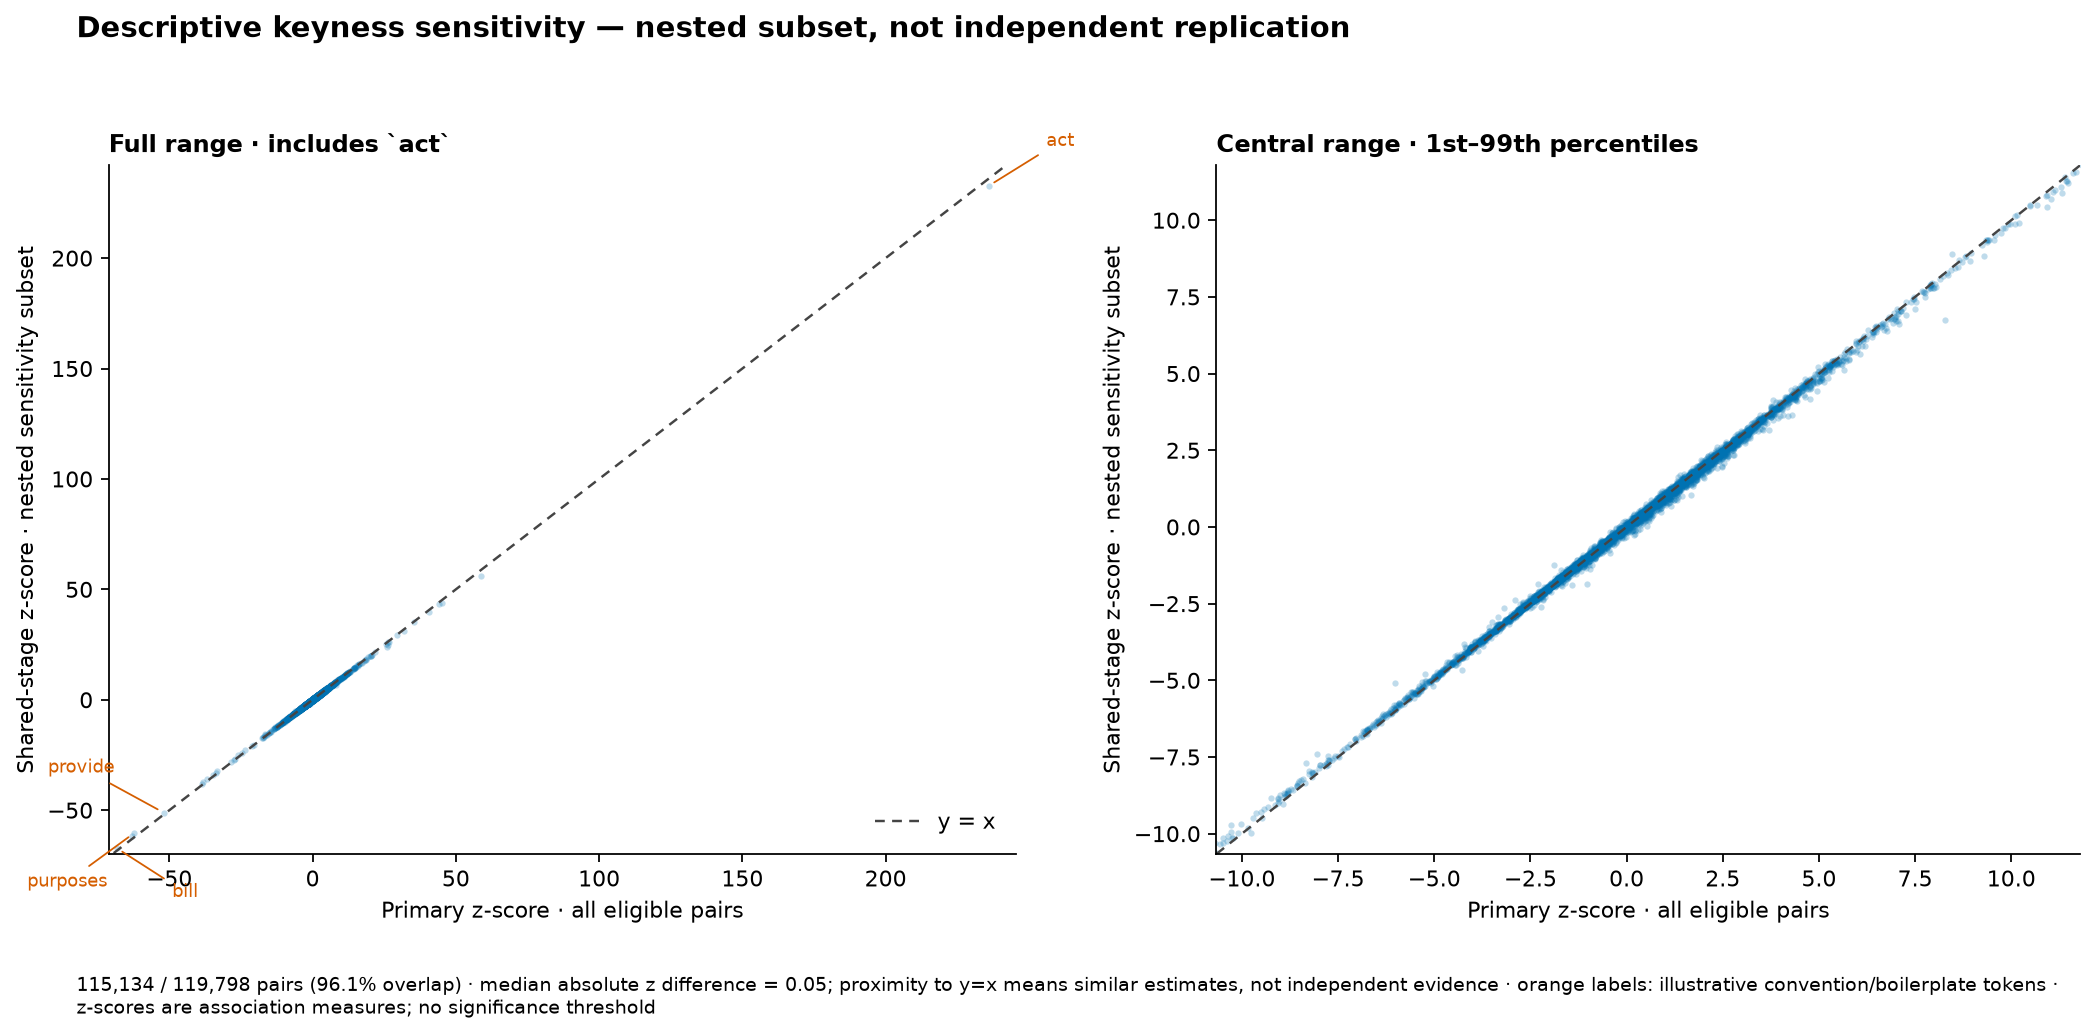

Saved reports/figures/gate3_primary_vs_shared_stage_keyness.png


In [4]:
d=primary[["token","z_score"]].merge(shared[["token","z_score"]],on="token",suffixes=("_primary","_shared")).dropna()
combined = pd.concat([d.z_score_primary, d.z_score_shared])
central_lo, central_hi = combined.quantile([0.01, 0.99])
mad_z = (d.z_score_primary-d.z_score_shared).abs().median()
fig,(ax_full,ax_central)=plt.subplots(1,2,figsize=(13.2,6.4),dpi=160,gridspec_kw={"width_ratios":[1.05,1]})
for ax in (ax_full, ax_central):
    ax.scatter(d.z_score_primary,d.z_score_shared,s=8,alpha=.25,color="#0072B2",linewidths=0,rasterized=True)
ax_full.plot([ax_full.get_xlim()[0],ax_full.get_xlim()[1]],[ax_full.get_xlim()[0],ax_full.get_xlim()[1]],color="#444444",lw=1.1,ls=(0,(4,3)),label="y = x")
ax_central.plot([central_lo,central_hi],[central_lo,central_hi],color="#444444",lw=1.1,ls=(0,(4,3)),label="y = x")
ax_full.set_xlim(d.z_score_primary.min()*1.04,d.z_score_primary.max()*1.04); ax_full.set_ylim(d.z_score_shared.min()*1.04,d.z_score_shared.max()*1.04)
ax_central.set_xlim(central_lo,central_hi); ax_central.set_ylim(central_lo,central_hi)
labels=["act","bill","purposes","provide"]
offsets={"act":(26,18),"bill":(25,-22),"purposes":(-48,-24),"provide":(-52,18)}
for t in labels:
    r=d.loc[d.token.eq(t)].iloc[0]
    ax_full.annotate(t,(r.z_score_primary,r.z_score_shared),xytext=offsets[t],textcoords="offset points",fontsize=8,color="#D55E00",arrowprops={"arrowstyle":"-","color":"#D55E00","lw":.8,"shrinkB":3})
ax_full.set_title("Full range · includes `act`",loc="left",fontsize=11,weight="bold")
ax_central.set_title("Central range · 1st–99th percentiles",loc="left",fontsize=11,weight="bold")
for ax in (ax_full,ax_central):
    ax.set_xlabel("Primary z-score · all eligible pairs"); ax.set_ylabel("Shared-stage z-score · nested sensitivity subset"); ax.spines[["top","right"]].set_visible(False); ax.grid(False)
ax_full.legend(frameon=False,loc="lower right")
fig.suptitle("Descriptive keyness sensitivity — nested subset, not independent replication",x=.04,ha="left",fontsize=13,weight="bold")
fig.text(.04,.005,f"115,134 / 119,798 pairs (96.1% overlap) · median absolute z difference = {mad_z:.2f}; proximity to y=x means similar estimates, not independent evidence · orange labels: illustrative convention/boilerplate tokens · z-scores are association measures; no significance threshold",ha="left",fontsize=8.5,wrap=True)
fig.tight_layout(rect=[0,.07,1,.94])
p=FIGURES/"gate3_primary_vs_shared_stage_keyness.png"; fig.savefig(p,dpi=160,bbox_inches="tight",facecolor="white"); plt.show(); print(f"Saved {p.relative_to(ROOT)}")


In [5]:
def stability(direction):
    c=f"{direction}_rank"; p=primary[primary[c]<=30][["token",c]].rename(columns={c:"primary_rank"}); s=shared[shared[c]<=30][["token",c]].rename(columns={c:"shared_rank"}); x=p.merge(s,on="token",how="outer"); x["direction"]=direction; x["rank_delta_shared_minus_primary"]=x.shared_rank-x.primary_rank; return x[["direction","token","primary_rank","shared_rank","rank_delta_shared_minus_primary"]]
ranks=pd.concat([stability("short"),stability("official")]).sort_values(["direction","primary_rank","token"],na_position="last")
display(Markdown("## Top-rank stability\n\n**Caveat.** Word association is not evidence of policy intent, value orientation, outcome, accessibility, or significance; counts are token frequencies, not document frequencies.\n\nUnion of primary/shared-stage top 30 for each direction; a missing rank is outside that table's top 30.")); display(ranks.style.format({"primary_rank":"{:.0f}","shared_rank":"{:.0f}","rank_delta_shared_minus_primary":"{:+.0f}"}).hide(axis="index"))


## Top-rank stability

**Caveat.** Word association is not evidence of policy intent, value orientation, outcome, accessibility, or significance; counts are token frequencies, not document frequencies.

Union of primary/shared-stage top 30 for each direction; a missing rank is outside that table's top 30.

direction,token,primary_rank,shared_rank,rank_delta_shared_minus_primary
official,bill,1,1,+0
official,amend,2,2,+0
official,purposes,3,3,+0
official,provide,4,4,+0
official,code,5,5,+0
official,states,6,6,+0
official,certain,7,7,+0
official,title,8,8,+0
official,establish,9,9,+0
official,united,10,10,+0


## Transparent metric candidate counts

The chart separates **Programmatic candidate flags** from **Readability eligibility**. Candidate flags are rule-based, overlapping indicators; readability bars are eligibility counts. The denominator is **119,798** canonical pairs. These are not validation or classification claims; later human annotation is required.


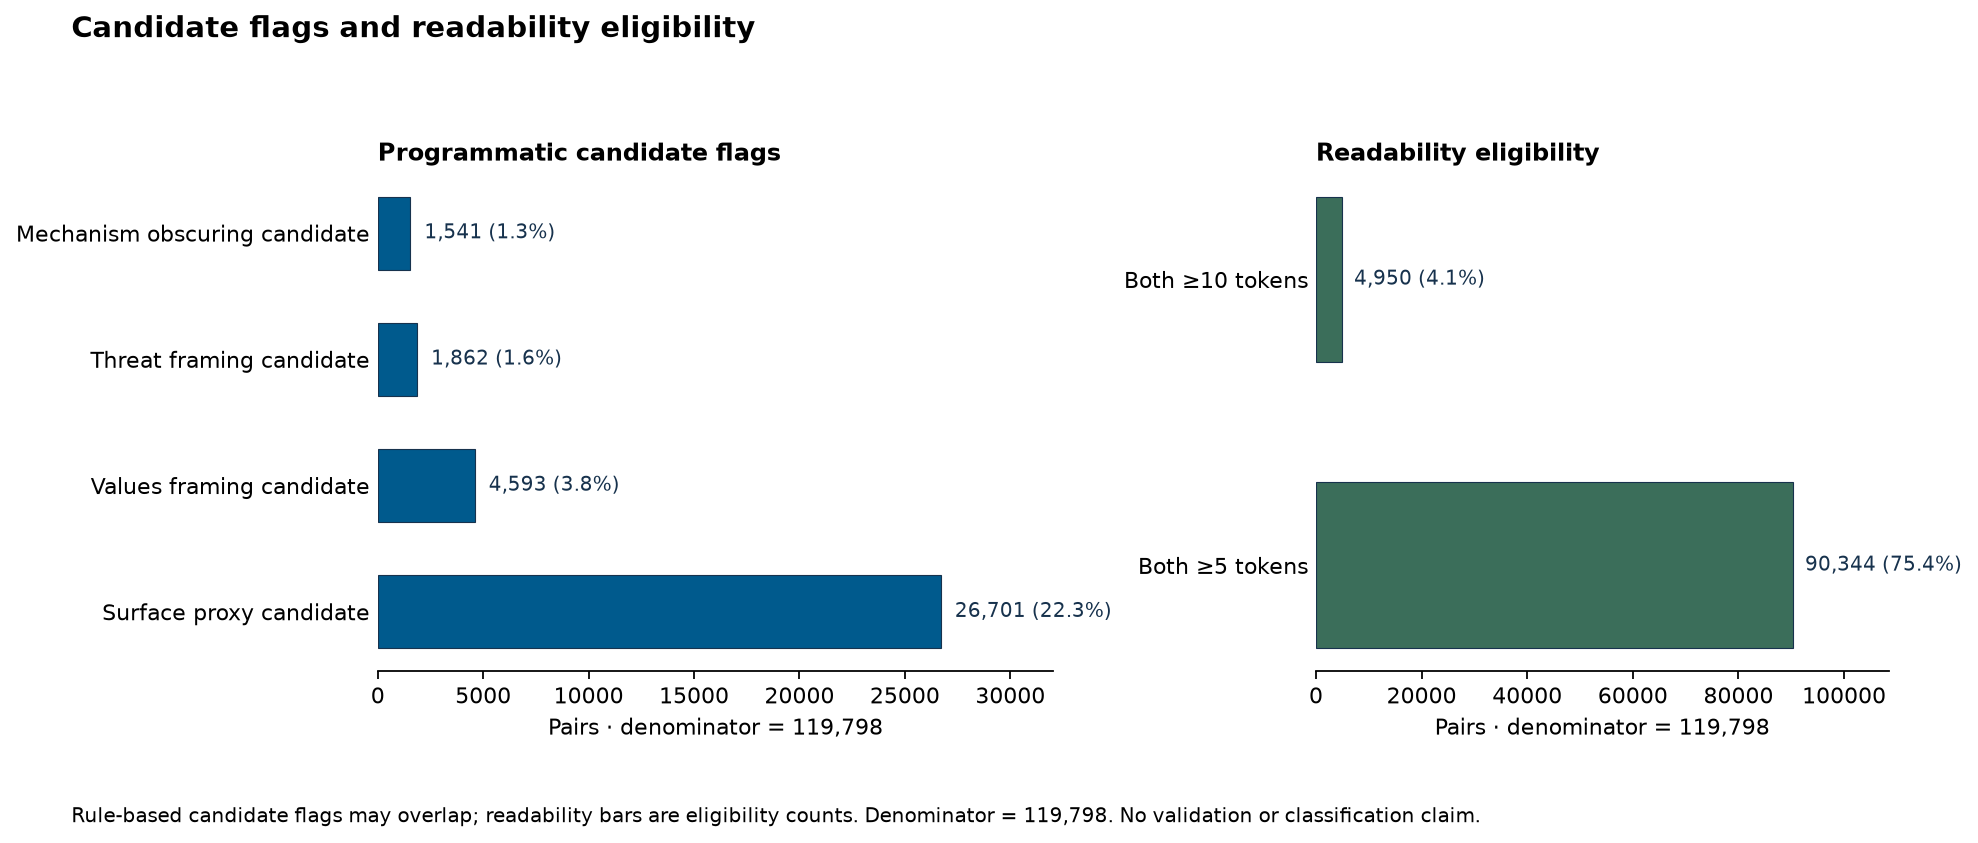

Saved reports/figures/gate3_metric_candidate_counts.png


In [6]:
cols={"Surface proxy candidate":"surface_simplification_candidate","Values framing candidate":"values_framing_candidate","Threat framing candidate":"threat_framing_candidate","Mechanism obscuring candidate":"mechanism_obscuring_candidate"}
counts=pd.Series({k:int(metrics[v].fillna(False).astype(bool).sum()) for k,v in cols.items()}); assert counts.to_dict()=={"Surface proxy candidate":26701,"Values framing candidate":4593,"Threat framing candidate":1862,"Mechanism obscuring candidate":1541}
read=pd.Series({"Both ≥5 tokens":""}); read=pd.Series({"Both ≥5 tokens":int(metrics.readability_both_eligible_5.fillna(False).astype(bool).sum()),"Both ≥10 tokens":int(metrics.readability_both_eligible_10.fillna(False).astype(bool).sum())}); assert read.to_dict()=={"Both ≥5 tokens":90344,"Both ≥10 tokens":4950}
fig,(ax_flags,ax_read)=plt.subplots(1,2,figsize=(12.4,5.2),dpi=160,gridspec_kw={"width_ratios":[1.18,1]})
for ax, vals, title, color in [(ax_flags,counts,"Programmatic candidate flags","#005A8D"),(ax_read,read,"Readability eligibility","#3B6E5A")]:
    bars=ax.barh(vals.index,vals.values,color=color,height=.58,edgecolor="#17324D",linewidth=.5)
    ax.set_xlim(0,max(vals)*1.2); ax.set_title(title,loc="left",fontsize=11,weight="bold"); ax.set_xlabel("Pairs · denominator = 119,798")
    for b,v in zip(bars,vals.values): ax.text(v+max(vals)*.025,b.get_y()+b.get_height()/2,f"{v:,} ({v/119798:.1%})",va="center",fontsize=9,color="#17324D")
    ax.spines[["top","right","left"]].set_visible(False); ax.tick_params(axis="y",length=0); ax.grid(False)
fig.suptitle("Candidate flags and readability eligibility",x=.04,ha="left",fontsize=13,weight="bold")
fig.text(.04,.01,"Rule-based candidate flags may overlap; readability bars are eligibility counts. Denominator = 119,798. No validation or classification claim.",ha="left",fontsize=9)
fig.tight_layout(rect=[0,.08,1,.92])
p=FIGURES/"gate3_metric_candidate_counts.png"; fig.savefig(p,dpi=160,bbox_inches="tight",facecolor="white"); plt.show(); print(f"Saved {p.relative_to(ROOT)}")


## Limitations and review notes

- The primary denominator is all 119,798 eligible pairs. The 115,134 shared-stage pairs are a nested sensitivity subset; the 96.1% overlap limits independence.
- Keyness is token-frequency comparison after the documented tokenizer and stopword policy. Relative rates are not posterior probabilities.
- Title conventions and boilerplate can drive visible terms, including `act`, `bill`, `amend`, `purposes`, `provide`, `code`, `states`, `title`, `united`, and `certain`. The `amend`/`amendments` split may be grammatical rather than two independent patterns.
- Candidate flags are transparent indicators, not claims; later human annotation is required.
- These outputs describe observed text. They do not establish bias, intent, persuasion, accessibility improvement, comprehension, policy quality, significance, importance, meaningfulness, causation, or classifier performance.